In [15]:
import pandas as pd
import numpy as np
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer


In [3]:
df = pd.read_json("NewsHeadline.json", lines=True)

In [4]:
df

,article_link,headline,is_sarcastic
0,https://www.huffingtonpost.com/entry/versace-b...,former versace store clerk sues over secret 'b...,0
1,https://www.huffingtonpost.com/entry/roseanne-...,the 'roseanne' revival catches up to our thorn...,0
2,https://local.theonion.com/mom-starting-to-fea...,mom starting to fear son's web series closest ...,1
3,https://politics.theonion.com/boehner-just-wan...,"boehner just wants wife to listen, not come up...",1
4,https://www.huffingtonpost.com/entry/jk-rowlin...,j.k. rowling wishes snape happy birthday in th...,0
...,...,...,...
26704,https://www.huffingtonpost.com/entry/american-...,american politics in moral free-fall,0
26705,https://www.huffingtonpost.com/entry/americas-...,america's best 20 hikes,0
26706,https://www.huffingtonpost.com/entry/reparatio...,reparations and obama,0
26707,https://www.huffingtonpost.com/entry/israeli-b...,israeli ban targeting boycott supporters raise...,0


In [7]:
df.isnull().sum()

,0
article_link,0
headline,0
is_sarcastic,0


In [8]:
df.shape

(26709, 3)

In [9]:
df.describe()

,is_sarcastic
count,26709.000000
mean,0.438953
std,0.496269
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,1.000000


In [17]:
nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [18]:
stopwords = set(stopwords.words('english'))

In [19]:
def preprocess_text(text):
    text = text.lower()
    words = nltk.word_tokenize(text)
    words = [word for word in words if word.isalpha()]
    words = [word for word in words if word not in stopwords]
    return " ".json(words)

In [39]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score

In [24]:
X = df["headline"]
y = df["is_sarcastic"]
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(X)

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [26]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

In [28]:
nb = MultinomialNB()
nb.fit(X_train, y_train)
nb_pred = nb.predict(X_test)

In [31]:
lr = LogisticRegression(max_iter = 1000)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

In [40]:
def evaluate_model(y_true, y_pred, model_name):
    print(f"Model: {model_name}")
    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred, average='weighted'))
    print("Recall   :", recall_score(y_true, y_pred, average='weighted'))
    print("F1 Score :", f1_score(y_true, y_pred, average='weighted'))
    print("\nClassification Report")
    cm = confusion_matrix(y_true, y_pred)
    print(cm)
    print(classification_report(y_true, y_pred))
    plt.figure(figsize=(7,6))

    sns.heatmap(cm,
                annot=True,
                fmt='d',
                cmap='Blues')

    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

Model: Naïve Bayes
Accuracy : 0.8139273680269562
Precision: 0.8259333742547457
Recall   : 0.8139273680269562
F1 Score : 0.808806621674639

Classification Report
[[2797  199]
 [ 795 1551]]
              precision    recall  f1-score   support

           0       0.78      0.93      0.85      2996
           1       0.89      0.66      0.76      2346

    accuracy                           0.81      5342
   macro avg       0.83      0.80      0.80      5342
weighted avg       0.83      0.81      0.81      5342



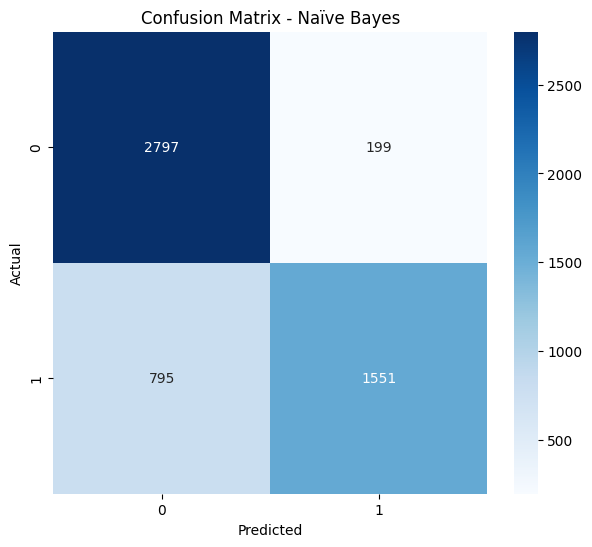

In [41]:
evaluate_model(y_test, nb_pred, "Naïve Bayes")

In [43]:
results = pd.DataFrame({
    'Model': ['Naïve Bayes', 'Logistic Regression'],
    'Accuracy': [accuracy_score(y_test, nb_pred), accuracy_score(y_test,lr_pred)],
    'Precision': [precision_score(y_test, nb_pred, average ='weighted'), precision_score(y_test, lr_pred, average = 'weighted')],
    'Recall score':[recall_score(y_test, nb_pred, average='weighted'), recall_score(y_test,lr_pred, average ='weighted')],
    'F1 score':[f1_score(y_test, nb_pred, average='weighted'), f1_score(y_test,lr_pred, average ='weighted')]
})
print(results)

                 Model  Accuracy  Precision  Recall score  F1 score
0          Naïve Bayes  0.813927   0.825933      0.813927  0.808807
1  Logistic Regression  0.845938   0.845748      0.845938  0.845806


In [45]:
df

,article_link,headline,is_sarcastic
0,https://www.huffingtonpost.com/entry/versace-b...,former versace store clerk sues over secret 'b...,0
1,https://www.huffingtonpost.com/entry/roseanne-...,the 'roseanne' revival catches up to our thorn...,0
2,https://local.theonion.com/mom-starting-to-fea...,mom starting to fear son's web series closest ...,1
3,https://politics.theonion.com/boehner-just-wan...,"boehner just wants wife to listen, not come up...",1
4,https://www.huffingtonpost.com/entry/jk-rowlin...,j.k. rowling wishes snape happy birthday in th...,0
...,...,...,...
26704,https://www.huffingtonpost.com/entry/american-...,american politics in moral free-fall,0
26705,https://www.huffingtonpost.com/entry/americas-...,america's best 20 hikes,0
26706,https://www.huffingtonpost.com/entry/reparatio...,reparations and obama,0
26707,https://www.huffingtonpost.com/entry/israeli-b...,israeli ban targeting boycott supporters raise...,0


In [46]:
import seaborn as sns
import matplotlib.pyplot as plt



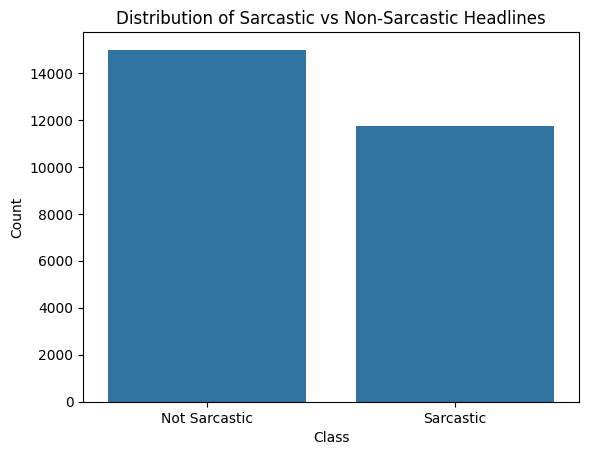

In [47]:
sns.countplot(x='is_sarcastic', data=df)
plt.title("Distribution of Sarcastic vs Non-Sarcastic Headlines")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks([0,1], ['Not Sarcastic','Sarcastic'])
plt.show()

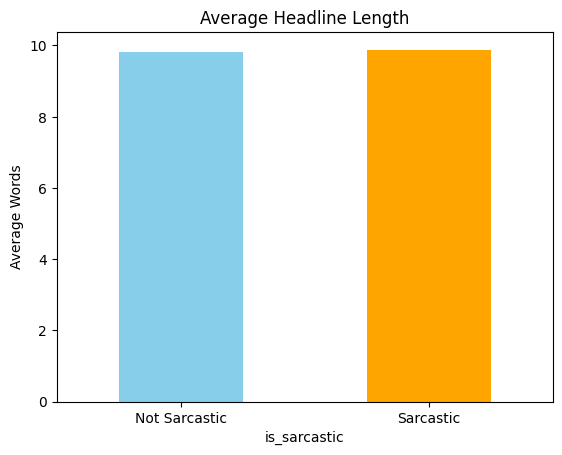

In [52]:
df['headline_length'] = df['headline'].apply(lambda x: len(x.split()))

df.groupby('is_sarcastic')['headline_length'].mean().plot(
    kind='bar',
    color=['skyblue','orange']
)

plt.xticks([0,1], ['Not Sarcastic','Sarcastic'], rotation=0)
plt.ylabel("Average Words")
plt.title("Average Headline Length")
plt.show()

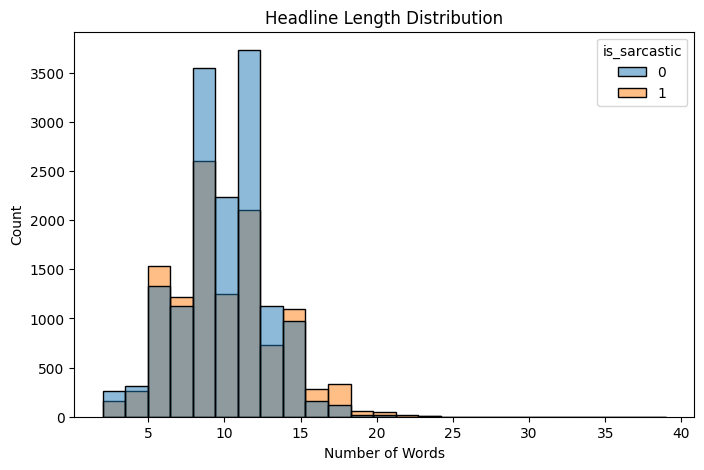

In [53]:
plt.figure(figsize=(8,5))
sns.histplot(df, x='headline_length', hue='is_sarcastic', bins=25)
plt.title("Headline Length Distribution")
plt.xlabel("Number of Words")
plt.show()

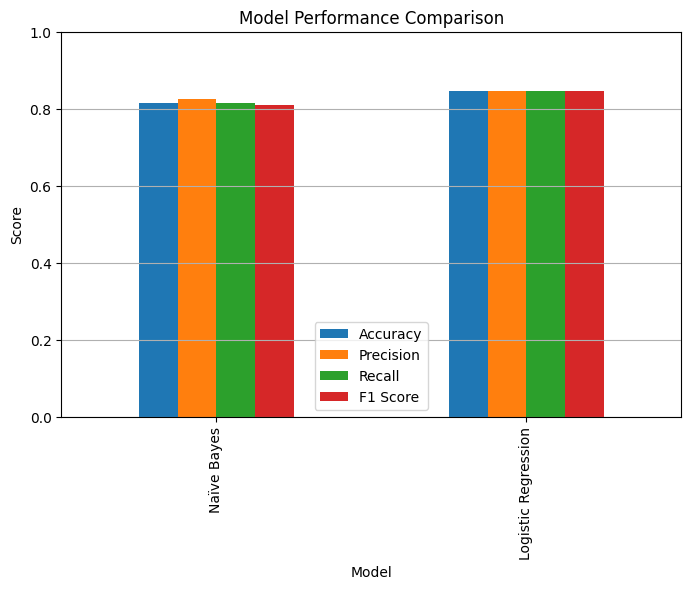

In [55]:
nb_acc = accuracy_score(y_test, nb_pred)
lr_acc = accuracy_score(y_test, lr_pred)
nb_pre = precision_score(y_test, nb_pred, average='weighted')
lr_pre = precision_score(y_test, lr_pred, average='weighted')
nb_rec = recall_score(y_test, nb_pred, average='weighted')
lr_rec = recall_score(y_test, lr_pred, average='weighted')
nb_f1 = f1_score(y_test, nb_pred, average='weighted')
lr_f1 = f1_score(y_test, lr_pred, average='weighted')

results = pd.DataFrame({
    'Model':['Naïve Bayes','Logistic Regression'],
    'Accuracy':[nb_acc, lr_acc],
    'Precision':[nb_pre, lr_pre],
    'Recall':[nb_rec, lr_rec],
    'F1 Score':[nb_f1, lr_f1]
})

results.set_index('Model').plot(kind='bar', figsize=(8,5))
plt.ylim(0,1)
plt.ylabel("Score")
plt.title("Model Performance Comparison")
plt.grid(axis='y')
plt.show()

In [56]:
from nltk.sentiment import SentimentIntensityAnalyzer
import nltk

nltk.download('vader_lexicon')

sia = SentimentIntensityAnalyzer()

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


In [57]:
df['sentiment_score'] = df['headline'].apply(
    lambda x: sia.polarity_scores(x)['compound']
)

In [58]:
def sentiment_label(score):
    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"

df["sentiment"] = df["sentiment_score"].apply(sentiment_label)

df.head()

,article_link,headline,is_sarcastic,headline_length,sentiment_score,sentiment
0,https://www.huffingtonpost.com/entry/versace-b...,former versace store clerk sues over secret 'b...,0,12,0.0000,Neutral
1,https://www.huffingtonpost.com/entry/roseanne-...,the 'roseanne' revival catches up to our thorn...,0,14,-0.3182,Negative
2,https://local.theonion.com/mom-starting-to-fea...,mom starting to fear son's web series closest ...,1,14,-0.4939,Negative
3,https://politics.theonion.com/boehner-just-wan...,"boehner just wants wife to listen, not come up...",1,13,0.0000,Neutral
4,https://www.huffingtonpost.com/entry/jk-rowlin...,j.k. rowling wishes snape happy birthday in th...,0,11,0.6486,Positive


/tmp/ipykernel_875/1100185665.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


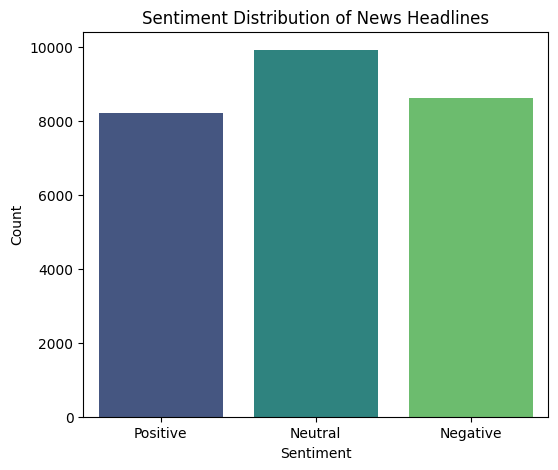

In [59]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="sentiment",
    order=["Positive","Neutral","Negative"],
    palette="viridis"
)

plt.title("Sentiment Distribution of News Headlines")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.show()

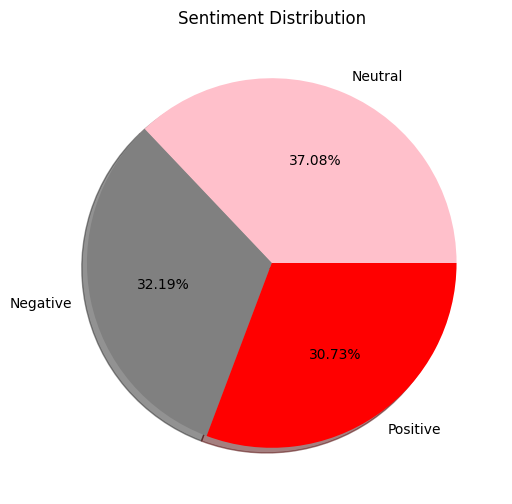

In [67]:
df["sentiment"].value_counts().plot(
    kind="pie",
    autopct="%1.2f%%",
    figsize=(6, 6),
    colors=["pink", "grey", "red"],
    shadow=True, )

plt.title("Sentiment Distribution")
plt.ylabel("")
plt.show()
